##  Setup & Imports

In [35]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import random
import torch
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, confusion_matrix
import torch.nn as nn
import kagglehub
import torch.nn.functional as F
import wandb
import os, gc, random, warnings, json
from tqdm import tqdm
from collections import Counter

from torch.cuda.amp import autocast, GradScaler
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR


from transformers import (
    ASTFeatureExtractor,
    ASTForAudioClassification,
    HubertModel,
    ASTConfig,
    Wav2Vec2FeatureExtractor,

)

import warnings
warnings.filterwarnings('ignore')


print("✅ All imports successful")
print(f"   PyTorch version     : {torch.__version__}")
print(f"   CUDA available      : {torch.cuda.is_available()}")

✅ All imports successful
   PyTorch version     : 2.8.0+cu126
   CUDA available      : False


In [2]:
"""
messy_mashup/
├── ESC-50-master/               ← Noise source only
│   ├── audio/                   ← 2,000 environmental sound clips (50 classes)
│   └── meta/esc50.csv           ← Metadata for noise clips
│
├── genres_stems/                ← TRAINING DATA ✅
│   ├── blues/                   ← 100 songs × 4 stems each
│   │   ├── song_001/
│   │   │   ├── drums.wav
│   │   │   ├── vocals.wav
│   │   │   ├── bass.wav
│   │   │   └── others.wav
│   │   └── ...
│   ├── classical/
│   ├── country/
│   ├── disco/
│   ├── hiphop/
│   ├── jazz/
│   ├── metal/
│   ├── pop/
│   ├── reggae/
│   └── rock/                    ← Total: 10 genres × 100 songs × 4 stems
│
├── mashups/                     ← TEST DATA ✅ (3,020 unlabeled audio files)
├── test.csv                     ← id → mashup filename mapping
└── sample_submission.csv        ← id, genre (template)
"""

'\nmessy_mashup/\n├── ESC-50-master/               ← Noise source only\n│   ├── audio/                   ← 2,000 environmental sound clips (50 classes)\n│   └── meta/esc50.csv           ← Metadata for noise clips\n│\n├── genres_stems/                ← TRAINING DATA ✅\n│   ├── blues/                   ← 100 songs × 4 stems each\n│   │   ├── song_001/\n│   │   │   ├── drums.wav\n│   │   │   ├── vocals.wav\n│   │   │   ├── bass.wav\n│   │   │   └── others.wav\n│   │   └── ...\n│   ├── classical/\n│   ├── country/\n│   ├── disco/\n│   ├── hiphop/\n│   ├── jazz/\n│   ├── metal/\n│   ├── pop/\n│   ├── reggae/\n│   └── rock/                    ← Total: 10 genres × 100 songs × 4 stems\n│\n├── mashups/                     ← TEST DATA ✅ (3,020 unlabeled audio files)\n├── test.csv                     ← id → mashup filename mapping\n└── sample_submission.csv        ← id, genre (template)\n'

In [2]:
### path configuration

BASE_DIR     = Path("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup")
STEMS_DIR    = BASE_DIR / "genres_stems"
ESC50_DIR    = BASE_DIR / "ESC-50-master"
MASHUPS_DIR  = BASE_DIR / "mashups" ### test data songs are present in this dir
TEST_CSV     = BASE_DIR / "test.csv"
SAMPLE_SUB   = BASE_DIR / "sample_submission.csv"
ESC50_META   = ESC50_DIR / "meta" / "esc50.csv"
ESC50_AUDIO_DIR =    ESC50_DIR/'audio'

GENRES = ["blues","classical","country","disco","hiphop",
          "jazz","metal","pop","reggae","rock"]
STEMS  = ["drums.wav","vocals.wav","bass.wav","other.wav"]

print("BASE_DIR exists:", BASE_DIR.exists())
print("Genres found   :", [g for g in GENRES if (STEMS_DIR/g).exists()])

BASE_DIR exists: True
Genres found   : ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


###  W&B project setup (for experiment tracking) and Huggingface setup for the uploadin model for deployment

In [3]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

# 1. Open the Kaggle vault
user_secrets = UserSecretsClient()

# 2. Extract your Hugging Face token
hf_api_key = user_secrets.get_secret("hf_token")

# 3. Log into the Hub silently
login(token=hf_api_key)

print("✅ Successfully authenticated with Hugging Face Hub!")

✅ Successfully authenticated with Hugging Face Hub!


In [4]:
import os
import wandb
from kaggle_secrets import UserSecretsClient

# 1. Open the Kaggle vault
user_secrets = UserSecretsClient()
wandb_api_key = user_secrets.get_secret("wandb")

# 2. Set it as an Environment Variable (Bypasses the 40-char limit)
os.environ["WANDB_API_KEY"] = wandb_api_key

# 3. Log in using the environment variable
wandb.login()

print("✅ Successfully authenticated using Service Account!")

wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


✅ Successfully authenticated using Service Account!


## Exploratory Data Analysis (EDA) 

Shape: (2000, 7)
            filename  fold  target        category  esc10  src_file take
0   1-100032-A-0.wav     1       0             dog   True    100032    A
1  1-100038-A-14.wav     1      14  chirping_birds  False    100038    A
2  1-100210-A-36.wav     1      36  vacuum_cleaner  False    100210    A
3  1-100210-B-36.wav     1      36  vacuum_cleaner  False    100210    B
4  1-101296-A-19.wav     1      19    thunderstorm  False    101296    A
total number of classes present in esc50 :  50
category
airplane            40
breathing           40
brushing_teeth      40
can_opening         40
car_horn            40
cat                 40
chainsaw            40
chirping_birds      40
church_bells        40
clapping            40
clock_alarm         40
clock_tick          40
coughing            40
cow                 40
crackling_fire      40
crickets            40
crow                40
crying_baby         40
dog                 40
door_wood_creaks    40
door_wood_knock     40
drinki

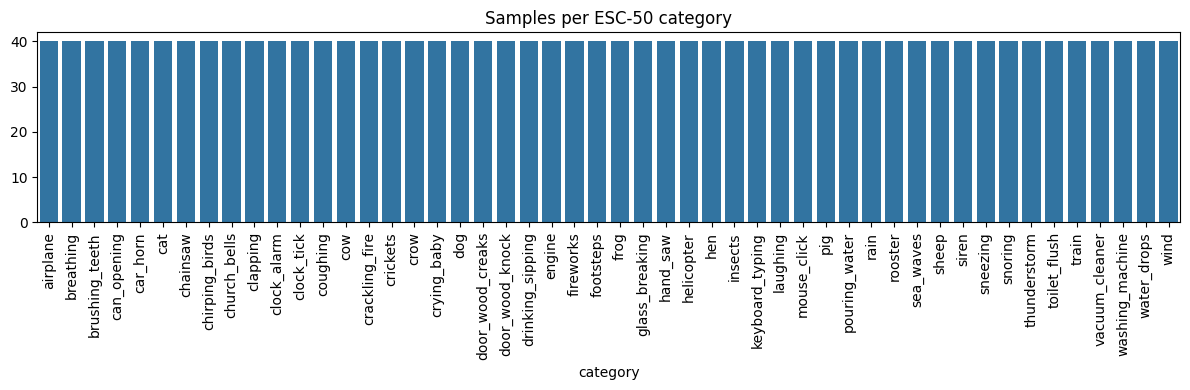

fold
1    400
2    400
3    400
4    400
5    400
Name: count, dtype: int64


In [9]:
### Understanding the noise dataset thoroughly
meta = pd.read_csv(ESC50_META)  # adjust path

print("Shape:", meta.shape)
print(meta.head())
print("="*100)
# Class distribution
class_counts = meta["category"].value_counts().sort_index()
class_len = len(meta["category"].value_counts().sort_index())
print("total number of classes present in esc50 : ",class_len)
print(class_counts)

plt.figure(figsize=(12, 4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.xticks(rotation=90)
plt.title("Samples per ESC-50 category")
plt.tight_layout()
plt.show()

# Fold distribution sanity check
print(meta["fold"].value_counts().sort_index())


#### Dataset Inventory & Class Balance Check

=== Dataset Inventory ===
           total_songs  complete_songs  missing_count
genre                                                
blues              100             100              0
classical          100             100              0
country            100             100              0
disco              100             100              0
hiphop             100             100              0
jazz               100             100              0
metal              100             100              0
pop                100             100              0
reggae             100             100              0
rock               100             100              0

✅ All songs have all 4 stems!


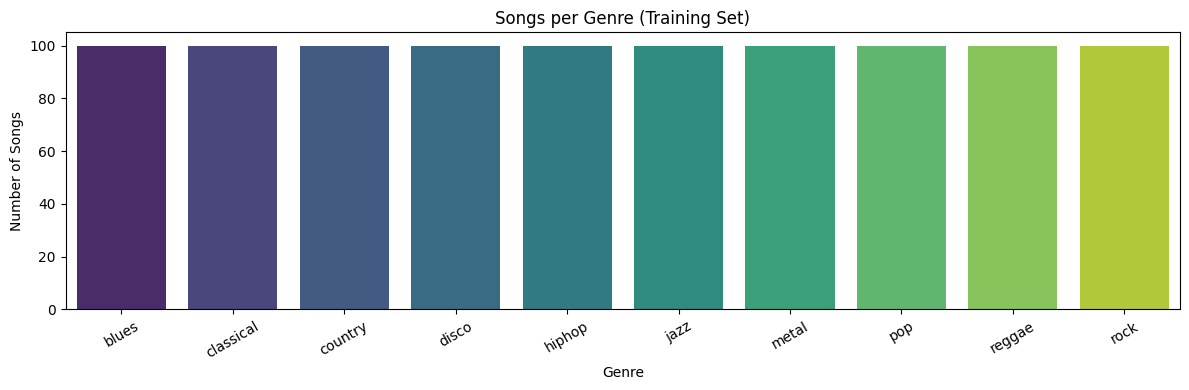

Total training songs: 1000
Total stem files    : 4000


In [6]:
# ── Count songs and stems per genre ──────────────────────────────────────────
inventory = []

for genre in GENRES:
    genre_path = STEMS_DIR / genre
    if not genre_path.exists():
        print(f" MISSING genre folder: {genre}")
        continue
    songs = [d for d in genre_path.iterdir() if d.is_dir()]
    for song in songs:
        stem_files = list(song.iterdir())
        stem_names = [f.name for f in stem_files]
        missing_stems = [s for s in STEMS if s not in stem_names]
        inventory.append({
            "genre"         : genre,
            "song"          : song.name,
            "n_stems"       : len(stem_files),
            "missing_stems" : missing_stems,
            "has_all_stems" : len(missing_stems) == 0
        })

df_inv = pd.DataFrame(inventory)
print("=== Dataset Inventory ===")
print(df_inv.groupby("genre").agg(
    total_songs    = ("song","count"),
    complete_songs = ("has_all_stems","sum"),
    missing_count  = ("has_all_stems", lambda x: (~x).sum())
).to_string())

# ── Flag missing stems ────────────────────────────────────────────────────────
broken = df_inv[df_inv["has_all_stems"] == False]
if len(broken):
    print(f"\n⚠️  {len(broken)} songs with missing stems:")
    print(broken[["genre","song","missing_stems"]])
else:
    print("\n✅ All songs have all 4 stems!")

# ── Bar chart: songs per genre ────────────────────────────────────────────────
genre_counts = df_inv.groupby("genre")["song"].count()
plt.figure(figsize=(12, 4))
sns.barplot(x=genre_counts.index, y=genre_counts.values, palette="viridis")
plt.title("Songs per Genre (Training Set)")
plt.ylabel("Number of Songs")
plt.xlabel("Genre")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("eda_01_class_balance.png", dpi=150)
plt.show()
print("Total training songs:", len(df_inv))
print("Total stem files    :", len(df_inv) * 4)


## Audio Properties: Sample Rate, Duration & Silence Detection

=== Audio Properties Summary ===
       sample_rate  duration_sec  rms_energy  active_ratio
count        120.0       120.000     120.000       120.000
mean       44100.0        30.032       0.060         0.961
std            0.0         0.076       0.044         0.122
min        44100.0        30.000       0.000         0.324
25%        44100.0        30.000       0.035         0.995
50%        44100.0        30.010       0.049         1.000
75%        44100.0        30.010       0.084         1.000
max        44100.0        30.370       0.210         1.000

📡 Sample Rate Distribution:
sample_rate
44100    120
Name: count, dtype: int64
⚠️  WARNING: Sample rate is NOT 22050 Hz — verify resampling needs!

⚠️  Silent stems found: 6
        genre             song    stem
12  classical  classical.00000   drums
16  classical  classical.00001   drums
17  classical  classical.00001  vocals
20  classical  classical.00002   drums
21  classical  classical.00002  vocals
65       jazz       jazz.00

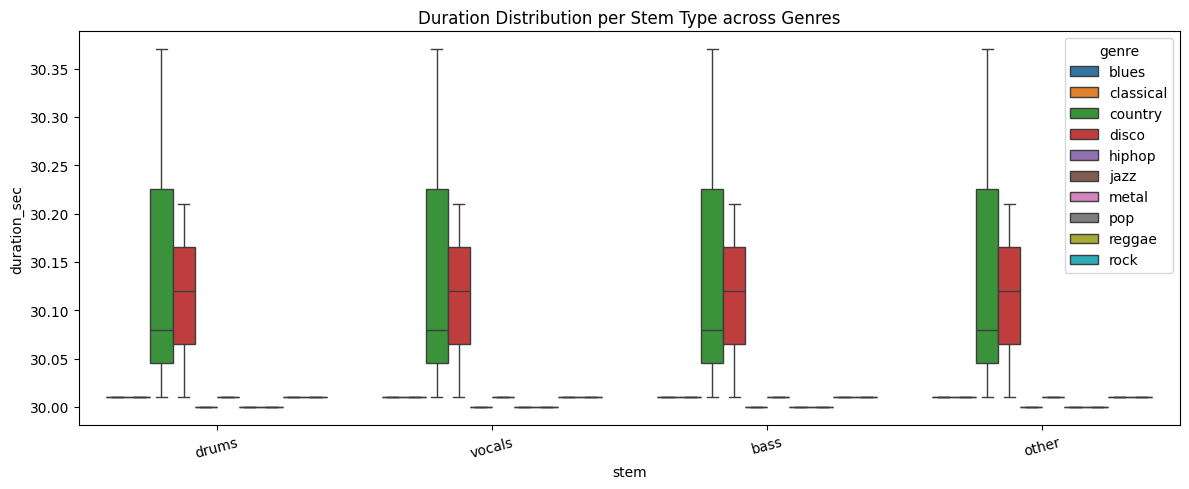

In [7]:
# ── Sample one song per genre, all 4 stems ───────────────────────────────────
audio_props = []

for genre in GENRES:
    genre_path = STEMS_DIR / genre
    songs      = sorted([d for d in genre_path.iterdir() if d.is_dir()])
    sample_songs = songs[:3]  # first 3 songs per genre for speed
    for song in sample_songs:
        for stem_name in STEMS:
            stem_path = song / stem_name
            if not stem_path.exists():
                continue
            try:
                y, sr    = librosa.load(str(stem_path), sr=None, mono=True)
                duration = librosa.get_duration(y=y, sr=sr)
                rms      = float(np.sqrt(np.mean(y**2)))
                is_silent= rms < 1e-4  # near-silent threshold

                # Silence ratio using librosa trim
                _, idx   = librosa.effects.trim(y, top_db=40)
                active_ratio = (idx[1] - idx[0]) / len(y)

                audio_props.append({
                    "genre"        : genre,
                    "song"         : song.name,
                    "stem"         : stem_name.replace(".wav",""),
                    "sample_rate"  : sr,
                    "duration_sec" : round(duration, 2),
                    "rms_energy"   : round(rms, 5),
                    "is_silent"    : is_silent,
                    "active_ratio" : round(active_ratio, 3)
                })
            except Exception as e:
                print(f"❌ Error reading {stem_path}: {e}")

df_props = pd.DataFrame(audio_props)
print("=== Audio Properties Summary ===")
print(df_props[["sample_rate","duration_sec","rms_energy","active_ratio"]].describe().round(3))

# ── Sample rate check ─────────────────────────────────────────────────────────
sr_counts = df_props["sample_rate"].value_counts()
print("\n📡 Sample Rate Distribution:")
print(sr_counts)
if sr_counts.index[0] != 22050:
    print("⚠️  WARNING: Sample rate is NOT 22050 Hz — verify resampling needs!")

# ── Silent stem warnings ──────────────────────────────────────────────────────
silent = df_props[df_props["is_silent"]]
print(f"\n⚠️  Silent stems found: {len(silent)}")
if len(silent): print(silent[["genre","song","stem"]])

# ── Duration distribution by stem type ───────────────────────────────────────
plt.figure(figsize=(12, 5))
sns.boxplot(data=df_props, x="stem", y="duration_sec", hue="genre", dodge=True)
plt.title("Duration Distribution per Stem Type across Genres")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("eda_02_duration_distribution.png", dpi=150)
plt.show()


## Mel Spectrogram Visualization (Clean Stem vs Noisy Mashup)

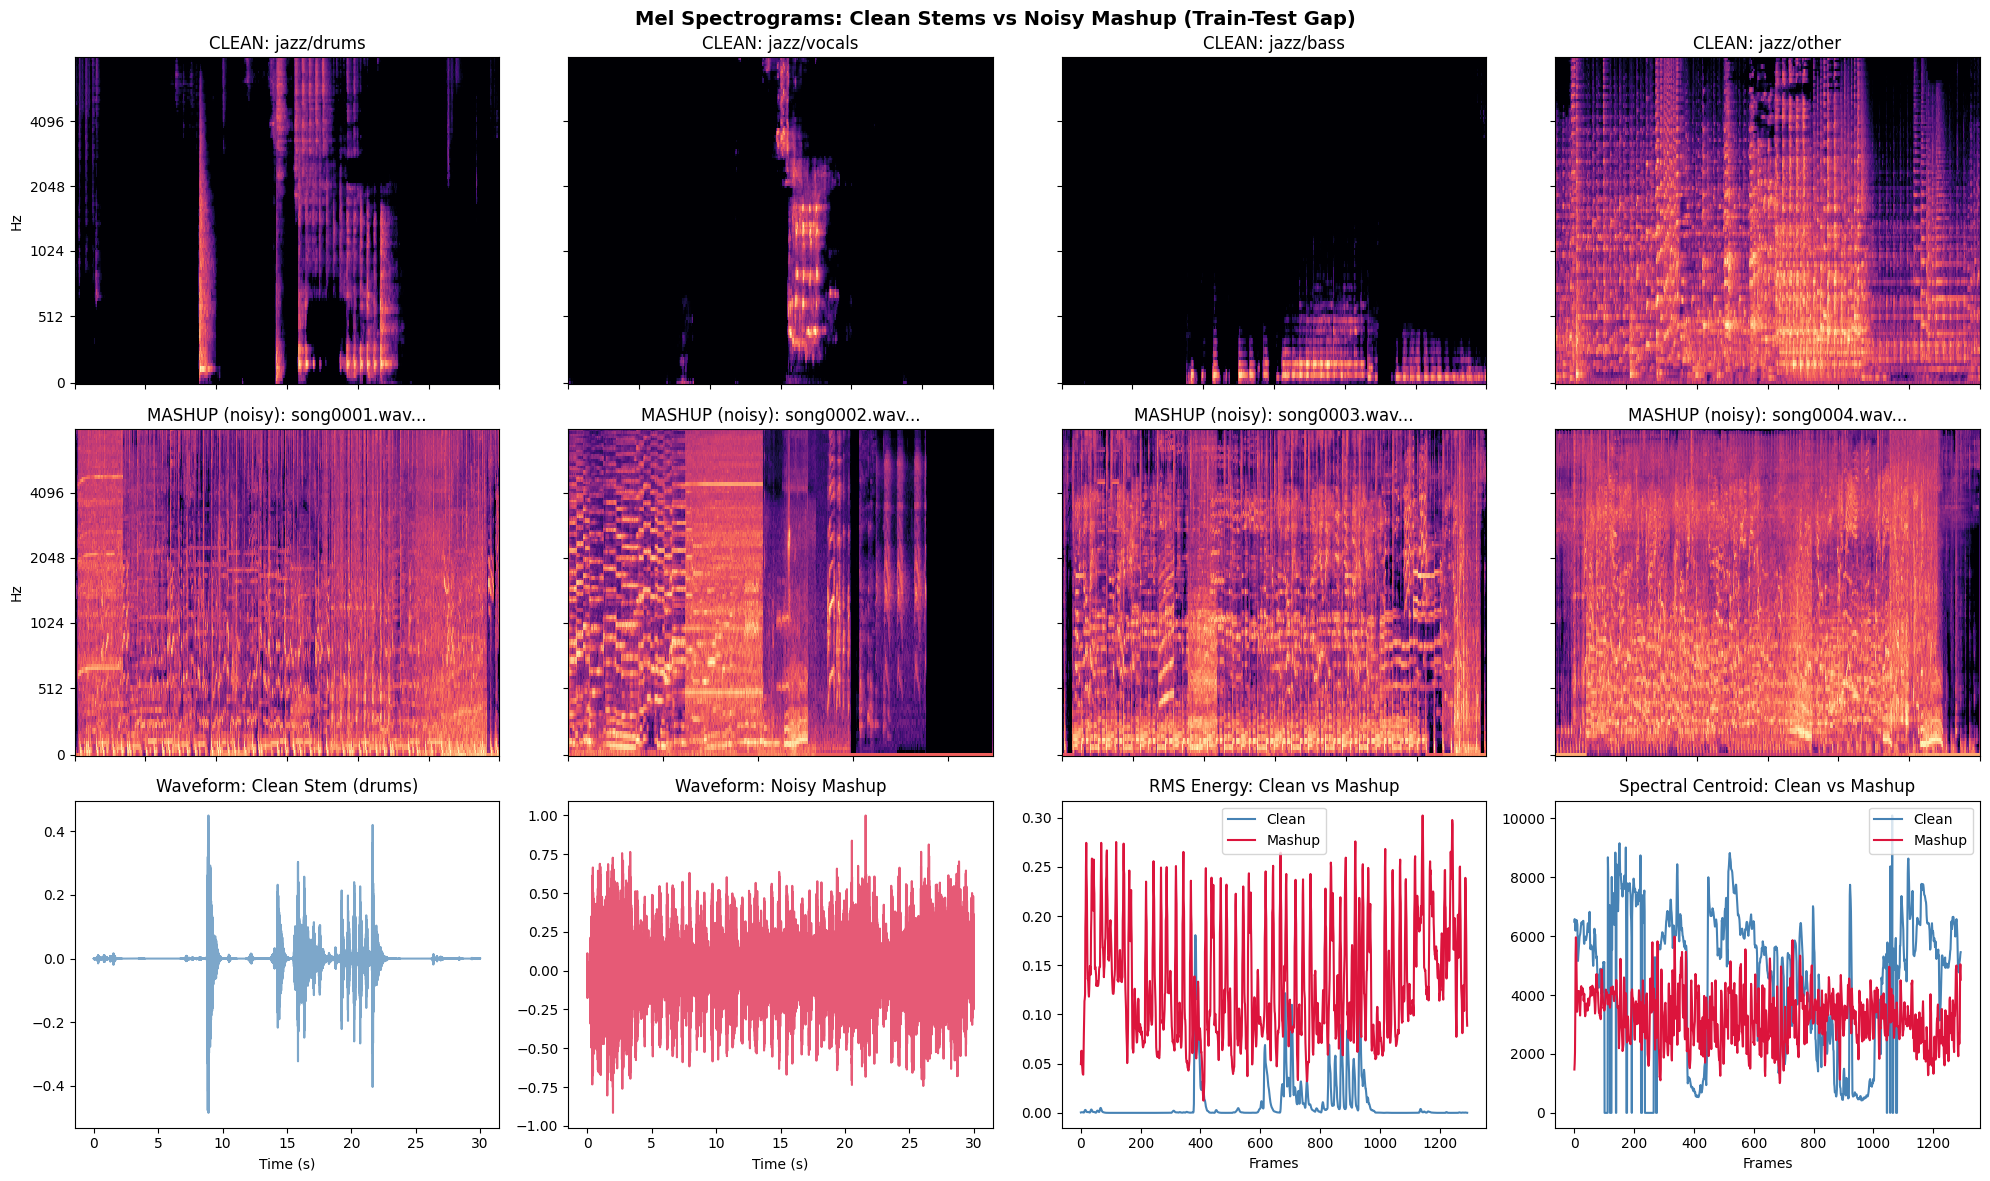

In [8]:
# ── KEY EDA: Visualize train-test distribution gap ────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle("Mel Spectrograms: Clean Stems vs Noisy Mashup (Train-Test Gap)", 
             fontsize=14, fontweight='bold')

# Plot one stem per genre (row 0-1) = clean stems
sample_genre = "jazz"
song_path    = sorted((STEMS_DIR / sample_genre).iterdir())[0]

for idx, stem_name in enumerate(STEMS):
    stem_path = song_path / stem_name
    y, sr     = librosa.load(str(stem_path), sr=22050, mono=True)
    mel       = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    mel_db    = librosa.power_to_db(mel, ref=np.max)
    ax        = axes[0][idx]
    librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel',
                             fmax=8000, ax=ax)
    ax.set_title(f"CLEAN: {sample_genre}/{stem_name.replace('.wav','')}")
    ax.label_outer()

# Plot 4 random mashups (row 1) = noisy test
mashup_files = sorted(MASHUPS_DIR.glob("*.wav"))[:4]
for idx, mf in enumerate(mashup_files):
    y, sr = librosa.load(str(mf), sr=22050, mono=True)
    mel   = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    mel_db= librosa.power_to_db(mel, ref=np.max)
    ax    = axes[1][idx]
    librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel',
                             fmax=8000, ax=ax)
    ax.set_title(f"MASHUP (noisy): {mf.name[:15]}...")
    ax.label_outer()

# Plot waveforms comparison (row 2)
y_clean, sr = librosa.load(str(song_path / "drums.wav"), sr=22050, mono=True)
y_noisy, _  = librosa.load(str(mashup_files[0]), sr=22050, mono=True)

# clean waveform
axes[2][0].plot(np.linspace(0, len(y_clean)/sr, len(y_clean)), y_clean, alpha=0.7, color='steelblue')
axes[2][0].set_title("Waveform: Clean Stem (drums)")
axes[2][0].set_xlabel("Time (s)")

# noisy mashup waveform
axes[2][1].plot(np.linspace(0, len(y_noisy)/sr, len(y_noisy)), y_noisy, alpha=0.7, color='crimson')
axes[2][1].set_title("Waveform: Noisy Mashup")
axes[2][1].set_xlabel("Time (s)")

# RMS energy over time
hop_length = 512
rms_clean = librosa.feature.rms(y=y_clean, hop_length=hop_length)[0]
rms_noisy = librosa.feature.rms(y=y_noisy, hop_length=hop_length)[0]
axes[2][2].plot(rms_clean, label='Clean', color='steelblue')
axes[2][2].plot(rms_noisy, label='Mashup', color='crimson')
axes[2][2].set_title("RMS Energy: Clean vs Mashup")
axes[2][2].legend()

# Spectral centroid comparison
sc_clean = librosa.feature.spectral_centroid(y=y_clean, sr=sr)[0]
sc_noisy = librosa.feature.spectral_centroid(y=y_noisy, sr=sr)[0]
axes[2][3].plot(sc_clean, label='Clean', color='steelblue')
axes[2][3].plot(sc_noisy, label='Mashup', color='crimson')
axes[2][3].set_title("Spectral Centroid: Clean vs Mashup")
axes[2][3].legend()

for ax in axes[2][2:]:
    ax.set_xlabel("Frames")

plt.tight_layout()
plt.savefig("eda_03_spectrogram_comparison.png", dpi=150)
plt.show()


## MFCC & Audio Feature Statistics per Genre

=== Feature Statistics per Genre ===
             tempo  zcr_mean  spec_bw_mean  chroma_mean
genre                                                  
blues      110.314     0.070      1826.065        0.354
classical  108.142     0.100      1547.978        0.240
country    115.528     0.106      2612.694        0.371
disco      115.888     0.147      2796.897        0.429
hiphop      99.422     0.101      2265.076        0.448
jazz       113.586     0.058      1365.744        0.286
metal      104.347     0.163      2450.956        0.504
pop         96.015     0.115      2848.125        0.402
reggae     129.001     0.081      2126.696        0.370
rock       116.355     0.061      1933.417        0.389


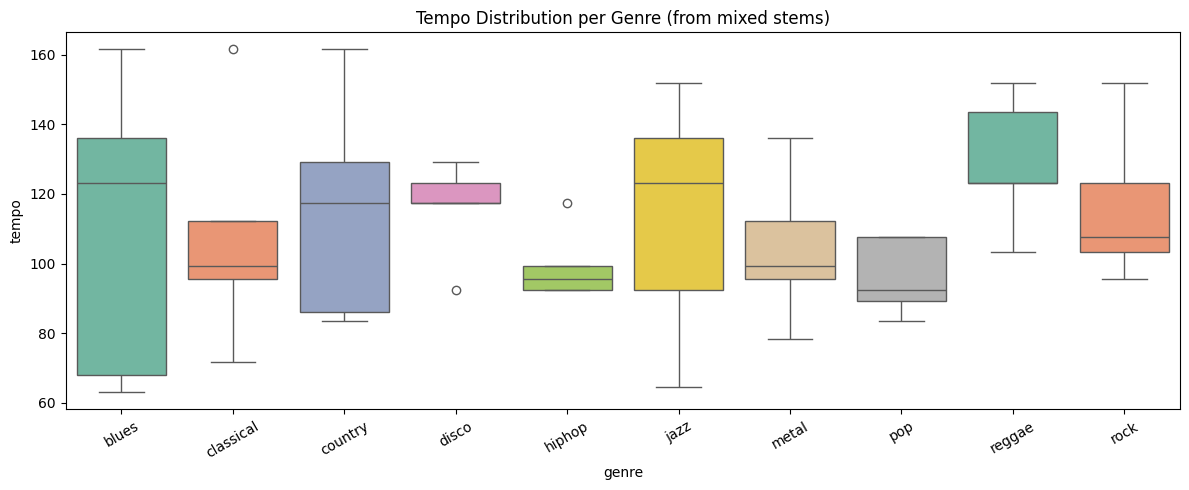

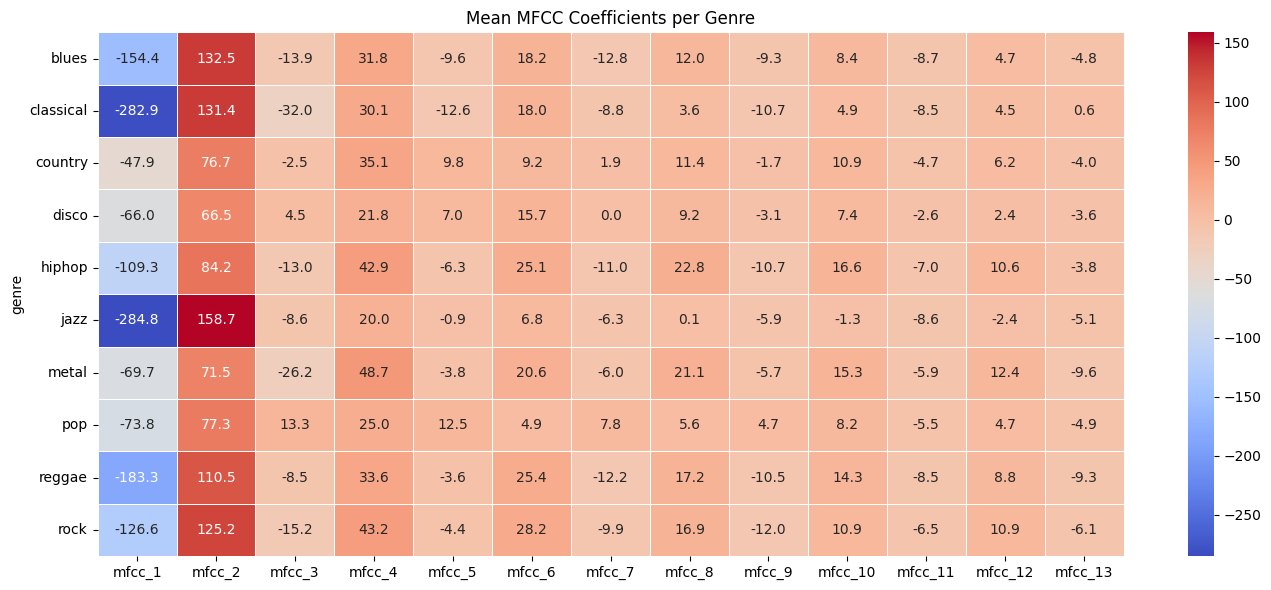

In [9]:
# ── Extract key features per genre for genre separability analysis ────────────
feature_records = []

for genre in GENRES:
    genre_path = STEMS_DIR / genre
    songs      = sorted([d for d in genre_path.iterdir() if d.is_dir()])[:5]
    for song in songs:
        # Mix all stems to simulate a full track
        mixed = None
        for stem_name in STEMS:
            stem_path = song / stem_name
            if not stem_path.exists(): continue
            y, sr = librosa.load(str(stem_path), sr=22050, mono=True, duration=30)
            mixed = y if mixed is None else mixed[:len(y)] + y[:len(mixed)]
        if mixed is None: continue

        mfcc      = librosa.feature.mfcc(y=mixed, sr=sr, n_mfcc=13)
        chroma    = librosa.feature.chroma_stft(y=mixed, sr=sr)
        spec_bw   = librosa.feature.spectral_bandwidth(y=mixed, sr=sr)
        zcr       = librosa.feature.zero_crossing_rate(mixed)
        tempo, _  = librosa.beat.beat_track(y=mixed, sr=sr)

        feature_records.append({
            "genre"        : genre,
            "song"         : song.name,
            "tempo"        : float(tempo),
            "zcr_mean"     : float(np.mean(zcr)),
            "spec_bw_mean" : float(np.mean(spec_bw)),
            "chroma_mean"  : float(np.mean(chroma)),
            **{f"mfcc_{i+1}": float(np.mean(mfcc[i])) for i in range(13)}
        })

df_feat = pd.DataFrame(feature_records)
print("=== Feature Statistics per Genre ===")
print(df_feat.groupby("genre")[["tempo","zcr_mean","spec_bw_mean","chroma_mean"]].mean().round(3))

# ── Tempo distribution per genre ─────────────────────────────────────────────
plt.figure(figsize=(12, 5))
sns.boxplot(data=df_feat, x="genre", y="tempo", palette="Set2")
plt.title("Tempo Distribution per Genre (from mixed stems)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("eda_04_tempo_per_genre.png", dpi=150)
plt.show()

# ── MFCC heatmap per genre ────────────────────────────────────────────────────
mfcc_cols  = [f"mfcc_{i}" for i in range(1, 14)]
mfcc_means = df_feat.groupby("genre")[mfcc_cols].mean()
plt.figure(figsize=(14, 6))
sns.heatmap(mfcc_means, annot=True, fmt=".1f", cmap="coolwarm", linewidths=0.5)
plt.title("Mean MFCC Coefficients per Genre")
plt.tight_layout()
plt.savefig("eda_04_mfcc_heatmap.png", dpi=150)
plt.show()

## ESC-50 Noise Analysis

=== ESC-50 Noise Dataset ===
(2000, 7)
            filename  fold  target        category  esc10  src_file take
0   1-100032-A-0.wav     1       0             dog   True    100032    A
1  1-100038-A-14.wav     1      14  chirping_birds  False    100038    A
2  1-100210-A-36.wav     1      36  vacuum_cleaner  False    100210    A

Columns: ['filename', 'fold', 'target', 'category', 'esc10', 'src_file', 'take']


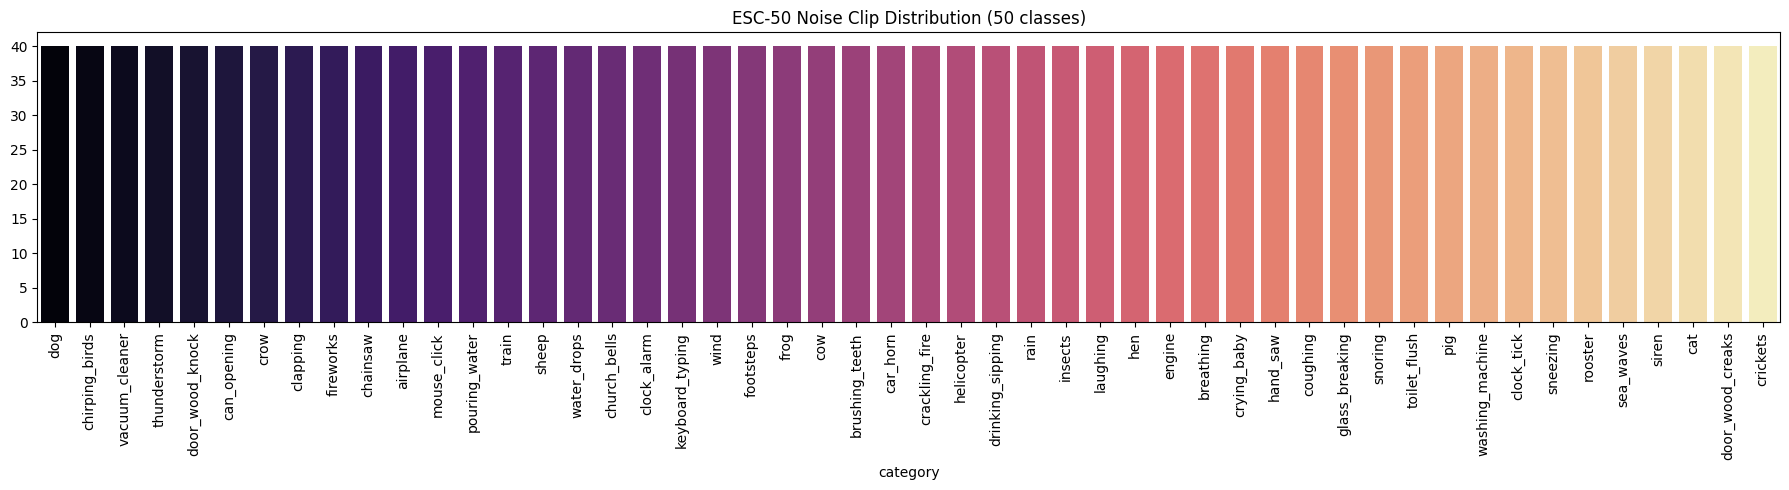

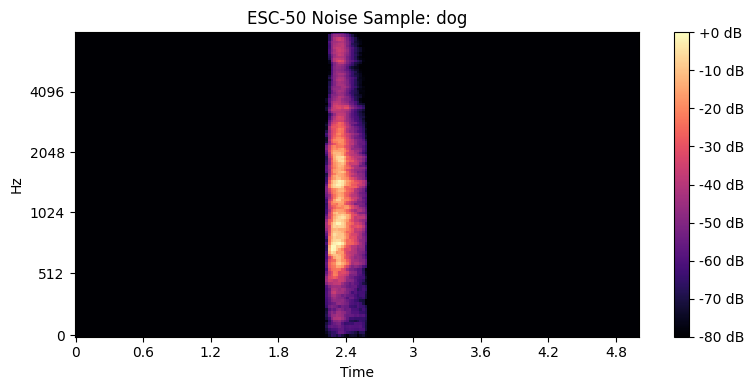

In [10]:
# ── Understand what noise will be mixed into test mashups ────────────────────
esc_meta = pd.read_csv(ESC50_META)
print("=== ESC-50 Noise Dataset ===")
print(esc_meta.shape)
print(esc_meta.head(3))
print("\nColumns:", esc_meta.columns.tolist())

# Class distribution
plt.figure(figsize=(18, 5))
cat_counts = esc_meta["category"].value_counts()
sns.barplot(x=cat_counts.index, y=cat_counts.values, palette="magma")
plt.title("ESC-50 Noise Clip Distribution (50 classes)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("eda_05_esc50_distribution.png", dpi=150)
plt.show()

# ── Sample noise mel spectrogram ──────────────────────────────────────────────
noise_sample = ESC50_DIR / "audio" / esc_meta["filename"].iloc[0]
y_noise, sr  = librosa.load(str(noise_sample), sr=22050, mono=True)
mel          = librosa.feature.melspectrogram(y=y_noise, sr=sr, n_mels=128)
mel_db       = librosa.power_to_db(mel, ref=np.max)

plt.figure(figsize=(8, 4))
librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', fmax=8000)
plt.colorbar(format="%+2.0f dB")
plt.title(f"ESC-50 Noise Sample: {esc_meta['category'].iloc[0]}")
plt.tight_layout()
plt.savefig("eda_05_esc50_noise_spectrogram.png", dpi=150)
plt.show()

## Test Set & Submission Sanity Check

=== test.csv ===
(3020, 2)
   id              filename
0   1  mashups/song0001.wav
1   2  mashups/song0002.wav
2   3  mashups/song0003.wav
3   4  mashups/song0004.wav
4   5  mashups/song0005.wav

=== sample_submission.csv ===
(3020, 2)
   id      genre
0   1       jazz
1   2      blues
2   3  classical
3   4        pop
4   5      disco

📁 Actual mashup files in folder: 3020
📋 Test CSV rows               : 3020
📋 Sample submission rows      : 3020

✅ test.csv and sample_submission.csv row counts match!


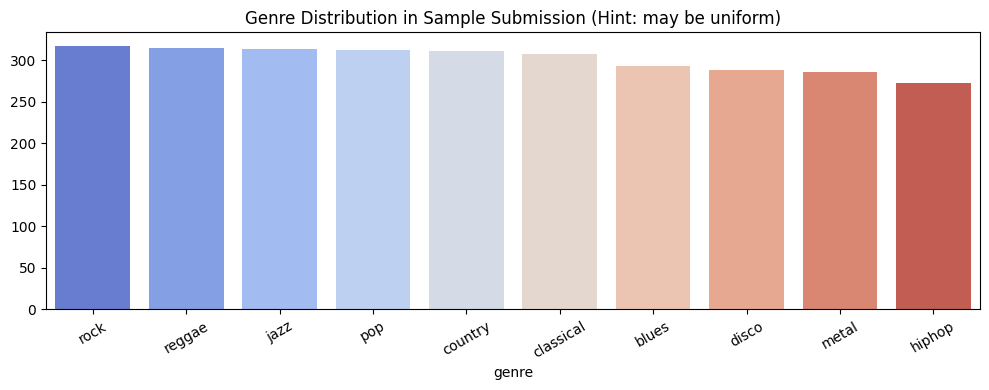


=== Mashup Audio Spot Check (50 files) ===
            sr  duration
count     50.0     50.00
mean   22050.0     29.11
std        0.0      3.29
min    22050.0     12.63
25%    22050.0     29.88
50%    22050.0     30.00
75%    22050.0     30.01
max    22050.0     30.29


In [11]:
# ── Test CSV inspection ───────────────────────────────────────────────────────
test_df   = pd.read_csv(TEST_CSV)
sub_df    = pd.read_csv(SAMPLE_SUB)
mashup_files = list(MASHUPS_DIR.glob("*.wav"))

print("=== test.csv ===")
print(test_df.shape)
print(test_df.head(5))
print("\n=== sample_submission.csv ===")
print(sub_df.shape)
print(sub_df.head(5))
print(f"\n📁 Actual mashup files in folder: {len(mashup_files)}")
print(f"📋 Test CSV rows               : {len(test_df)}")
print(f"📋 Sample submission rows      : {len(sub_df)}")

# ── Verify IDs match ──────────────────────────────────────────────────────────
assert len(test_df) == len(sub_df), "⚠️ test.csv and sample_submission row count mismatch!"
print("\n✅ test.csv and sample_submission.csv row counts match!")

# ── Genre distribution in sample submission ───────────────────────────────────
plt.figure(figsize=(10, 4))
sub_genre_counts = sub_df["genre"].value_counts()
sns.barplot(x=sub_genre_counts.index, y=sub_genre_counts.values, palette="coolwarm")
plt.title("Genre Distribution in Sample Submission (Hint: may be uniform)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("eda_06_submission_distribution.png", dpi=150)
plt.show()

# ── Mashup audio property spot check ─────────────────────────────────────────
mashup_props = []
for mf in mashup_files[:50]:  # spot check 50
    y, sr    = librosa.load(str(mf), sr=None, mono=True)
    duration = librosa.get_duration(y=y, sr=sr)
    mashup_props.append({"file": mf.name, "sr": sr, "duration": round(duration,2)})

df_mashup = pd.DataFrame(mashup_props)
print("\n=== Mashup Audio Spot Check (50 files) ===")
print(df_mashup[["sr","duration"]].describe().round(2))


In [5]:
meta_df = pd.read_csv(ESC50_META)
print(meta_df.shape)
print(meta_df.head())

(2000, 7)
            filename  fold  target        category  esc10  src_file take
0   1-100032-A-0.wav     1       0             dog   True    100032    A
1  1-100038-A-14.wav     1      14  chirping_birds  False    100038    A
2  1-100210-A-36.wav     1      36  vacuum_cleaner  False    100210    A
3  1-100210-B-36.wav     1      36  vacuum_cleaner  False    100210    B
4  1-101296-A-19.wav     1      19    thunderstorm  False    101296    A


In [9]:
def load_audio(path: Path) -> np.ndarray:
    """
    Load WAV, resample to CFG.SAMPLE_RATE, mono.
    """
    y, sr = librosa.load(str(path), sr=CFG.SAMPLE_RATE, mono=True)
    return y

def is_silent(y: np.ndarray) -> bool:
    """
    Detect near-silent clip via RMS.
    """
    rms = float(np.sqrt(np.mean(y ** 2)))
    return rms < CFG.SILENT_RMS

def audio_to_melspec(y: np.ndarray) -> np.ndarray:
    """
    Convert waveform -> log-mel spectrogram (np.ndarray [n_mels, T]).
    """
    if is_silent(y):
        # ESC-50 should not have silent clips, but guard anyway
        # Replace with tiny noise instead of crashing.
        y = np.random.normal(scale=1e-6, size=y.shape).astype(np.float32)

    S = librosa.feature.melspectrogram(
        y=y,
        sr=CFG.SAMPLE_RATE,
        n_fft=CFG.N_FFT,
        hop_length=CFG.HOP_LENGTH,
        win_length=CFG.WIN_LENGTH,
        n_mels=CFG.N_MELS,
        fmin=CFG.FMIN,
        fmax=CFG.FMAX,
        center=True,
        power=2.0,
    )
    S_db = librosa.power_to_db(S, ref=np.max)
    return S_db.astype(np.float32)


##   MASTER CONFIG

In [38]:
import kagglehub
import torch.nn.functional as F

class CFG:
    # ── Audio ──────────────────────────────────────────────
    SAMPLE_RATE   = 16000
    CLIP_DURATION = 10
    CLIP_SAMPLES  = 16000 * 10   # 160,000
    SILENT_RMS    = 1e-4

    # ── Mel params ─────────────────────────────────────────
    N_FFT         = 1024
    HOP_LENGTH    = 320
    WIN_LENGTH    = 1024
    N_MELS        = 128
    FMIN          = 0
    FMAX          = 8000

    # ── Augmentation ───────────────────────────────────────
    P_TIME_STRETCH     = 0.5
    P_PITCH_SHIFT      = 0.4
    P_NOISE_ADD        = 0.8
    P_GAIN             = 0.5
    P_SPEC_AUGMENT     = 0.7
    MIXUP_ALPHA        = 0.2
    P_MIXUP            = 0.3
    TIME_STRETCH_RANGE = (0.85, 1.15)
    PITCH_SHIFT_RANGE  = (-2, 2)
    SNR_RANGE          = (5, 20)
    GAIN_RANGE         = (0.6, 1.4)

    # ── Labels ─────────────────────────────────────────────
    GENRES    = ["blues","classical","country","disco","hiphop",
                 "jazz","metal","pop","reggae","rock"]
    NUM_CLASSES = 10
    GENRE2IDX   = {g: i for i, g in enumerate(GENRES)}
    IDX2GENRE   = {i: g for i, g in enumerate(GENRES)}

    # ── KaggleHub handles ──────────────────────────────────
    KAGGLE_HANDLE_CRNN   = "vikas25s/messy-mashup/pytorch/crnn"
    KAGGLE_HANDLE_AST    = "vikas25s/messy-mashup/pytorch/ast"
    KAGGLE_HANDLE_HUBERT = "vikas25s/messy-mashup/pytorch/hubert"

print("✅ CFG loaded")
print(f"   Genres to idx : {CFG.GENRE2IDX}")
print(f"   Clip   : {CFG.CLIP_DURATION}s = {CFG.CLIP_SAMPLES} samples at {CFG.SAMPLE_RATE}Hz")

✅ CFG loaded
   Genres to idx : {'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4, 'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9}
   Clip   : 10s = 160000 samples at 16000Hz


Waveform length: 80000 samples at 16000 Hz
Mel-spectrogram shape: (128, 251)


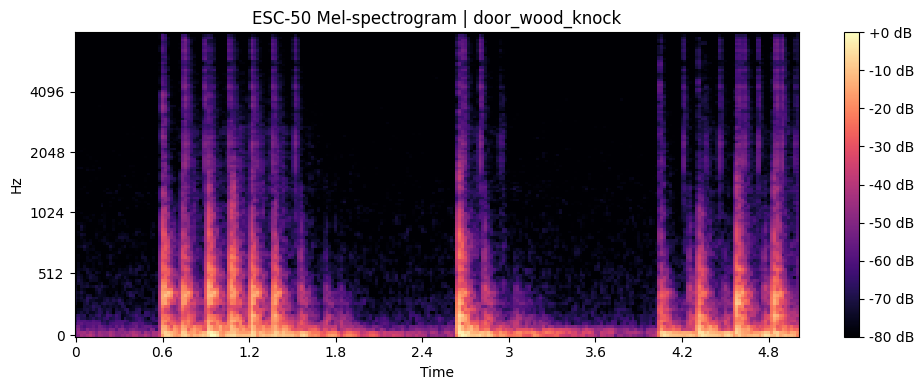

In [13]:
### Quick check 
import matplotlib.pyplot as plt
import librosa.display


sample_row = meta_df.sample(1).iloc[0]
fname      = sample_row["filename"]
category   = sample_row["category"]

y = load_audio(ESC50_AUDIO_DIR / fname)
S_db = audio_to_melspec(y)
print("Waveform length:", len(y), "samples at", CFG.SAMPLE_RATE, "Hz")
print("Mel-spectrogram shape:", S_db.shape)

plt.figure(figsize=(10, 4))
librosa.display.specshow(
    S_db,
    sr=CFG.SAMPLE_RATE,
    hop_length=CFG.HOP_LENGTH,
    x_axis="time",
    y_axis="mel",
    fmax=CFG.FMAX,
)
plt.colorbar(format="%+2.0f dB")
plt.title(f"ESC-50 Mel-spectrogram | {category}")
plt.tight_layout()
plt.show()


## All handles

In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

### Audio utitlites functions

In [24]:
def load_audio(path):
    y, sr = librosa.load(str(path), sr=CFG.SAMPLE_RATE, mono=True)## loading the audio for the
    return y
    
def is_silent(y):
    rms = float(np.sqrt(np.mean(y ** 2)))  ## check the silent with silent rms 1-e4
    return rms < CFG.SILENT_RMS

def audio_to_melspec(y):
    if is_silent(y):
        y = np.random.normal(scale=1e-6, size=y.shape).astype(np.float32)
    S = librosa.feature.melspectrogram(
        y=y,
        sr=CFG.SAMPLE_RATE,
        n_fft=CFG.N_FFT,
        hop_length=CFG.HOP_LENGTH,
        win_length=CFG.WIN_LENGTH,
        n_mels=CFG.N_MELS,
        fmin=CFG.FMIN,
        fmax=CFG.FMAX,
        power=2.0,
        center=True,
    )
    S_db = librosa.power_to_db(S, ref=np.max)
    return S_db.astype(np.float32)
    
def random_crop(y, length=CFG.CLIP_SAMPLES):
    if len(y) >= length:
        start = random.randint(0, len(y) - length)
        return y[start : start + length]
    # Pad with zeros if too short
    return np.pad(y, (0, length - len(y)), mode='constant')

### STEM MIXING — Most Important Augmentation

In [25]:
def build_song_pool():
    pool = {}
    for genre in GENRES:
        genre_path = STEMS_DIR / genre
        songs = sorted([d for d in genre_path.iterdir() if d.is_dir()])
        pool[genre] = songs
        print(f"   {genre:12s} → {len(songs)} songs")
    return pool  ## Returns: {genre: [list of song folder Paths]}


def mix_stems_from_genre(genre, song_pool):
    songs = song_pool[genre]
    mixed = None
    for stem_name in STEMS:
        # Pick a DIFFERENT random song for EACH stem
        song_path = random.choice(songs)
        stem_path = song_path / stem_name

        if not stem_path.exists():
            continue

        y = load_audio(stem_path)
        print(y)

        # Skip silent stems (classical drums, jazz vocals etc.)
        if is_silent(y):
            continue

        # Random gain — simulates instrument balance in mashup
        if random.random() < CFG.P_GAIN:
            gain = random.uniform(*CFG.GAIN_RANGE)
            y    = y * gain
        y = random_crop(y, CFG.CLIP_SAMPLES)

        # Add to mix
        mixed = y if mixed is None else mixed + y

    # Fallback if all stems were silent (very rare)
    if mixed is None:
        return np.zeros(CFG.CLIP_SAMPLES, dtype=np.float32)

    # Normalize to prevent clipping after adding 4 stems
    # WHY: adding 4 signals can push amplitude to 4x max
    # Clipping causes harsh distortion in spectrogram
    max_val = np.abs(mixed).max()
    if max_val > 0:
        mixed = mixed / max_val

    return mixed.astype(np.float32)

def normalize_waveform(y: np.ndarray) -> np.ndarray:
    peak = np.abs(y).max()
    return (y / peak).astype(np.float32) if peak > 0 else y.astype(np.float32)

### WAVEFORM AUGMENTATIONS

In [28]:
## Time Stretch 
def augment_time_stretch(y):
    rate = random.uniform(*CFG.TIME_STRETCH_RANGE)
    y_stretched = librosa.effects.time_stretch(y, rate=rate)
    # Re-crop after stretch (length changes after stretching)
    return random_crop(y_stretched, CFG.CLIP_SAMPLES)

# Pitch Shift
def augment_pitch_shift(y):
    n_steps = random.uniform(*CFG.PITCH_SHIFT_RANGE)
    return librosa.effects.pitch_shift(
        y, sr=CFG.SAMPLE_RATE, n_steps=n_steps
    )
    
class SpecAugment:
    def __init__(self, apply=True):
        self.apply = apply
        self.fm    = T.FrequencyMasking(24)
        self.tm    = T.TimeMasking(96)

    def __call__(self, x):
        if self.apply and random.random() < CFG.P_SPEC_AUGMENT:
            x = self.fm(x)
            x = self.tm(x)
        return x
        

class Mixup:
    def __init__(self, alpha=CFG.MIXUP_ALPHA):
        self.alpha = alpha
    def mix(self, y1, l1, y2, l2):
        lam        = float(np.random.beta(self.alpha, self.alpha))
        mixed      = normalize_waveform(lam * y1 + (1 - lam) * y2)
        soft       = np.zeros(CFG.NUM_CLASSES, dtype=np.float32)
        soft[l1]  += lam
        soft[l2]  += (1 - lam)
        return mixed, soft

spec_augment = SpecAugment()
mixup        = Mixup()
print("✅ Augmentations")

✅ Augmentations


In [ ]:
# ============================================================
#  ESC50NoiseMixer — Production-ready, 0.95+ target
# ============================================================

class ESC50NoiseMixer:
    """
    3 principles: fold discipline | curriculum | stable val noise
    + fixes: noise probability gate, random tile offset,
             expanded MUSICAL_ADJACENT, warm-up clean phase,
             multi-fold compatible.
    """

    MUSICAL_ADJACENT = {
        # Tonal / melodic
        "music_box", "church_bells", "hand_saw",
        # Rhythmic / percussive
        "clapping", "clock_tick", "clock_alarm",
        "footsteps", "fireworks", "train",
        # Textural (masks frequency features)
        "crackling_fire", "thunderstorm",
    }


    def __init__(self, val_fold=5):
        meta = pd.read_csv(ESC50_DIR / "meta" / "esc50.csv")
        self.audio_dir   = ESC50_DIR / "audio"
        self.val_fold    = val_fold
        self._in_warmup  = True
        self._noise_prob = 0.5   # will be updated by step_epoch()

        train_meta    = meta[meta["fold"] != val_fold].copy()
        self.val_meta = (meta[meta["fold"] == val_fold]
                             .copy()
                             .reset_index(drop=True))

        self._train_meta = train_meta
        self.train_pool  = None
        self.step_epoch(current_epoch=0, total_epochs=1)

        print(f"  ESC50NoiseMixer ready | val_fold={val_fold} | "
              f"val_clips={len(self.val_meta)}")

    # ─────────────────────────────────────────────────────
    def step_epoch(self, current_epoch, total_epochs):
        """
        Call at the START of every training epoch.
        Rebuilds train_pool and updates curriculum stage.
        """
        self.update(current_epoch, total_epochs)

    # ─────────────────────────────────────────────────────
    def update(self, current_epoch, total_epochs):
        progress = current_epoch / max(total_epochs, 1)

        # ── Warm-up: first 5% epochs → clean only ─────────
        self._in_warmup = (progress < 0.05)

        # ── Noise application probability schedule ─────────
        if progress < 0.05:
            self._noise_prob = 0.0    # warm-up: no noise
        elif progress < 0.33:
            self._noise_prob = 0.50   # easy stage: 50% noisy
        elif progress < 0.66:
            self._noise_prob = 0.75   # mid stage
        else:
            self._noise_prob = 0.90   # hard stage

        # ── Curriculum pool selection ──────────────────────
        if progress < 0.33:
            pool  = self._train_meta[self._train_meta["esc10"] == True].copy()
            stage = "ESC-10 only"
        elif progress < 0.66:
            pool  = self._train_meta[
                ~self._train_meta["category"].isin(self.MUSICAL_ADJACENT)
            ].copy()
            stage = "non-musical"
        else:
            pool  = self._train_meta.copy()
            stage = "full ESC-50"

        # ── Stratified weighting ───────────────────────────
        counts = pool["category"].value_counts()
        pool   = pool.copy()
        pool["weight"]  = pool["category"].map(lambda c: 1.0 / counts[c])
        pool["weight"] /= pool["weight"].sum()
        self.train_pool = pool.reset_index(drop=True)

        print(f"  ESC50 | ep{current_epoch}/{total_epochs} | "
              f"stage={stage} | p={self._noise_prob:.2f} | "
              f"pool={len(self.train_pool)}")

    # ─────────────────────────────────────────────────────
    def _mix(self, signal, noise, snr_db):
        # Random circular shift before tiling for variety
        if len(noise) > 1:
            offset = random.randint(0, len(noise) - 1)
            noise  = np.roll(noise, offset)

        # Tile then crop to match signal length exactly
        if len(noise) < len(signal):
            repeats = int(np.ceil(len(signal) / len(noise)))
            noise   = np.tile(noise, repeats)
        noise = noise[:len(signal)]

        rms_s = float(np.sqrt(np.mean(signal ** 2)))
        rms_n = float(np.sqrt(np.mean(noise  ** 2)))

        if rms_s < 1e-9 or rms_n < 1e-9:
            return signal.astype(np.float32)

        scale = rms_s / (10 ** (snr_db / 20.0)) / rms_n
        mixed = signal + noise * scale

        mx = np.abs(mixed).max()
        if mx > 0:
            mixed = mixed / mx
        return mixed.astype(np.float32)

    # ─────────────────────────────────────────────────────
    def add_noise_train(self, y):
        assert self.train_pool is not None, \
            "Call noise_mixer.step_epoch(epoch, total) before each epoch!"

        # Probability gate: sometimes return clean audio
        if random.random() > self._noise_prob:
            return y.astype(np.float32)

        row   = self.train_pool.sample(n=1, weights="weight").iloc[0]
        noise = load_audio(self.audio_dir / row["filename"])
        snr   = random.uniform(*CFG.SNR_RANGE)
        return self._mix(y, noise, snr)

    # ─────────────────────────────────────────────────────
    def add_noise_val(self, y, clip_idx=0):
        """Fixed noise per val sample — same every epoch."""
        idx   = clip_idx % len(self.val_meta)
        row   = self.val_meta.iloc[idx]
        noise = load_audio(self.audio_dir / row["filename"])
        return self._mix(y, noise, snr_db=15.0)


# ── Per-fold instantiation (inside your fold loop) ────────────
# DO NOT use a single global instance if you run 5-fold CV.
# noise_mixer = ESC50NoiseMixer(val_fold=fold)


## DATASET and data Loaders for each model

### CRNNdatset for the simple crnn

In [37]:
class CRNNDataset(Dataset):
    
    def __init__(self,
                 song_pool,
                 noise_mixer,
                 n_samples_per_genre=200,
                 augment=True,
                 is_test=False):
        self.song_pool   = song_pool
        self.noise_mixer = noise_mixer
        self.augment     = augment
        self.is_test     = is_test
        self.spec_aug    = SpecAugment(apply=augment)
        
        if not is_test:
            self.samples = [
                g for g in GENRES
                for _ in range(n_samples_per_genre)
            ]
            random.shuffle(self.samples)
            print(f"✅ MelDataset [{'train' if augment else 'val'}] "
                  f"| {len(self.samples)} samples "
                  f"| {n_samples_per_genre}/genre")
        else:
            self.test_df = pd.read_csv(CFG.TEST_CSV)
            print(f"✅ MelDataset [test] | {len(self.test_df)} files")

    def __len__(self):
        return len(self.test_df) if self.is_test else len(self.samples)
        
    def _wav_to_mel(self, y):
        """Convert waveform → normalised mel spectrogram tensor."""
        mel    = librosa.feature.melspectrogram(
            y          = y,
            sr         = CFG.SAMPLE_RATE,
            n_mels     = CFG.N_MELS,
            n_fft      = CFG.N_FFT,
            hop_length = CFG.HOP_LENGTH,
            win_length = CFG.WIN_LENGTH,
            fmax       = CFG.FMAX
        )
        mel_db = librosa.power_to_db(mel, ref=np.max)  # (128, T)

        # Enforce fixed width = 1000 frames
        target_t = CFG.CLIP_SAMPLES // CFG.HOP_LENGTH   # 1000
        if mel_db.shape[1] >= target_t:
            mel_db = mel_db[:, :target_t]
        else:
            mel_db = np.pad(
                mel_db,
                ((0, 0), (0, target_t - mel_db.shape[1])),
                mode='constant'
            )
        mu    = mel_db.mean()
        sigma = mel_db.std() + 1e-6
        mel_db = (mel_db - mu) / sigma

        # Add channel dim → (1, 128, 1000)
        return torch.tensor(mel_db, dtype=torch.float32).unsqueeze(0)

    
    def __getitem__(self, idx):
        # ── Test mode ─────────────────────────────────────
        if self.is_test:
            row  = self.test_df.iloc[idx]
            y    = load_audio(CFG.BASE_DIR / row["filename"])
            y    = random_crop(y, CFG.CLIP_SAMPLES)
            mel  = self._wav_to_mel(y)
            return mel, row["id"]

        # ── Train / val mode ───────────────────────────────
        genre = self.samples[idx]
        y     = mix_stems_from_genre(genre, self.song_pool)

        if self.augment:
            if random.random() < CFG.P_TIME_STRETCH:
                y = augment_time_stretch(y)
            if random.random() < CFG.P_PITCH_SHIFT:
                y = augment_pitch_shift(y)
            if random.random() < CFG.P_NOISE_ADD:
                y = self.noise_mixer.add_noise(y)

        mel   = self._wav_to_mel(y)
        mel   = self.spec_aug(mel)
        label = CFG.GENRE2IDX[genre]
        return mel, torch.tensor(label, dtype=torch.long)


### ATS  train and test datset for astclassifier

In [36]:
# Load ONCE globally — reuse in both datasets
feature_extractor = ASTFeatureExtractor.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593"
)

print(f"✅ ASTFeatureExtractor loaded")
print(f"   sampling_rate : {feature_extractor.sampling_rate}")
print(f"   mean          : {feature_extractor.mean:.4f}")
print(f"   std           : {feature_extractor.std:.4f}")
print(f"   max_length    : {feature_extractor.max_length}")

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

✅ ASTFeatureExtractor loaded
   sampling_rate : 16000
   mean          : -4.2677
   std           : 4.5690
   max_length    : 1024


In [ ]:
class ASTTrainDataset(Dataset):
    def __init__(self, song_pool, noise_mixer,
                 n_samples_per_genre=200, augment=True):
        self.song_pool   = song_pool
        self.noise_mixer = noise_mixer
        self.augment     = augment
        self.spec_aug    = SpecAugment(apply=augment)
        self.samples = []
        for genre in GENRES:
            for _ in range(n_samples_per_genre):
                self.samples.append(genre)
        random.shuffle(self.samples)

        total = len(self.samples)
        print(f"✅ TrainDataset ready: {total} samples "
              f"({n_samples_per_genre}/genre) | augment={augment}")
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        genre = self.samples[idx]
        label = CFG.GENRE2IDX[genre]

        # ── 1: Mix stems from different songs ─────────────
        y = mix_stems_from_genre(genre, self.song_pool)

        # ── 2: Waveform augmentations (train only) ─────────
        if self.augment:
            if random.random() < CFG.P_TIME_STRETCH:
                y = augment_time_stretch(y)
            if random.random() < CFG.P_PITCH_SHIFT:
                y = augment_pitch_shift(y)
            if random.random() < CFG.P_NOISE_ADD:
                y = self.noise_mixer.add_noise(y)

        # ── 3: ASTFeatureExtractor → fbank features ────────
        # Input : numpy array (160000,) at 16kHz
        # Output: tensor (1, 1024, 128)
        inputs = feature_extractor(
            y,
            sampling_rate  = CFG.SAMPLE_RATE,
            return_tensors = "pt",
            padding        = "max_length",
        )
        fbank = inputs["input_values"]   # shape: (1, 1024, 128)

        # ── 4: SpecAugment on fbank (train only) ───────────
        fbank = self.spec_aug(fbank)     # shape: (1, 1024, 128)

        return fbank, torch.tensor(label, dtype=torch.long)

class ASTTestDataset(Dataset):
    def __init__(self):
        self.test_df = pd.read_csv(TEST_CSV)
        print(f"✅ TestDataset ready: {len(self.test_df)} mashup files")

    def __len__(self):
        return len(self.test_df)

    def __getitem__(self, idx):
        row       = self.test_df.iloc[idx]
        file_path = CFG.BASE_DIR / row["filename"]

        # Load mashup audio
        y = load_audio(file_path)
        y = random_crop(y, CFG.CLIP_SAMPLES)

        # ASTFeatureExtractor (same settings, no SpecAugment)
        inputs = feature_extractor(
            y,
            sampling_rate  = CFG.SAMPLE_RATE,
            return_tensors = "pt",
            padding        = "max_length",
        )

        return fbank, row["id"]

### Hubert datset 

In [ ]:
class HuBERTDataset(Dataset):
    def __init__(self,
                 feature_extractor,
                 song_pool,
                 noise_mixer,
                 n_samples_per_genre=200,
                 augment=True,
                 is_test=False):
        self.fe          = feature_extractor
        self.song_pool   = song_pool
        self.noise_mixer = noise_mixer
        self.augment     = augment
        self.is_test     = is_test

        if not is_test:
            self.samples = [
                g for g in CFG.GENRES
                for _ in range(n_samples_per_genre)
            ]
            random.shuffle(self.samples)
            print(f"✅ HuBERTDataset [{'train' if augment else 'val'}] "
                  f"| {len(self.samples)} samples "
                  f"| {n_samples_per_genre}/genre")
        else:
            self.test_df = pd.read_csv(CFG.TEST_CSV)
            print(f"✅ HuBERTDataset [test] | {len(self.test_df)} files")

    
    def __len__(self):
        return len(self.test_df) if self.is_test else len(self.samples)

    def _wav_to_input(self, y):
        """Normalise waveform via Wav2Vec2FeatureExtractor."""
        out = self.fe(
            y,
            sampling_rate  = CFG.SAMPLE_RATE,
            return_tensors = "pt",
            padding        = "max_length",
            max_length     = CFG.CLIP_SAMPLES,
            truncation     = True,
        )
        return out["input_values"]   # (1, 160000)


    def __getitem__(self, idx):
            # ── Test mode ─────────────────────────────────────
            if self.is_test:
                row = self.test_df.iloc[idx]
                y   = load_audio(CFG.BASE_DIR / row["filename"])
                y   = random_crop(y, CFG.CLIP_SAMPLES)
                wav = self._wav_to_input(y)
                return wav, row["id"]
    
            # ── Train / val mode ───────────────────────────────
            genre = self.samples[idx]
            y     = mix_stems_from_genre(genre, self.song_pool)
    
            if self.augment:
                if random.random() < CFG.P_TIME_STRETCH:
                    y = augment_time_stretch(y)
                if random.random() < CFG.P_PITCH_SHIFT:
                    y = augment_pitch_shift(y)
                if random.random() < CFG.P_NOISE_ADD:
                    y = self.noise_mixer.add_noise(y)
                    
            wav   = self._wav_to_input(y)
            label = CFG.GENRE2IDX[genre]
            return wav, torch.tensor(label, dtype=torch.long)



In [ ]:
## dataset sanity check 
def check_dataset_shapes(song_pool):
    print("\n🔍 Dataset shape check...")

    # MelDataset
    mel_ds  = MelDataset(song_pool, train_noise_mixer,
                          n_samples_per_genre=2, augment=True)
    mx, my  = mel_ds[0]
    assert mx.shape == torch.Size([1, 128, 1000]), \
        f"❌ MelDataset shape {mx.shape}"
    print(f"  ✅ MelDataset     : {tuple(mx.shape)}  "
          f"label={CFG.IDX2GENRE[my.item()]}")

    # ASTDataset
    fe_ast  = ASTFeatureExtractor.from_pretrained(
                "MIT/ast-finetuned-audioset-10-10-0.4593")
    ast_ds  = ASTDataset(fe_ast, song_pool, train_noise_mixer,
                          n_samples_per_genre=2, augment=True)
    ax, ay  = ast_ds[0]
    assert ax.shape == torch.Size([1, 1024, 128]), \
        f"❌ ASTDataset shape {ax.shape}"
    print(f"  ✅ ASTDataset     : {tuple(ax.shape)}  "
          f"label={CFG.IDX2GENRE[ay.item()]}")
    # HuBERTDataset
    fe_hub  = Wav2Vec2FeatureExtractor.from_pretrained(
                "facebook/hubert-base-ls960")
    hub_ds  = HuBERTDataset(fe_hub, song_pool, train_noise_mixer,
                             n_samples_per_genre=2, augment=True)
    hx, hy  = hub_ds[0]
    assert hx.shape == torch.Size([1, 160000]), \
        f"❌ HuBERTDataset shape {hx.shape}"
    print(f"  ✅ HuBERTDataset  : {tuple(hx.shape)}  "
          f"label={CFG.IDX2GENRE[hy.item()]}")

    print("\n✅ All dataset shapes correct!")

### CRNN Model

In [ ]:
class CRNN(nn.Module):
    def __init__(self, n_mels=CFG.N_MELS, n_classes=len(CFG.GENRES)):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.pool  = nn.MaxPool2d((2, 2))

        self.gru_hidden = 128
        self.gru = nn.GRU(
            input_size=64 * (n_mels // 4),
            hidden_size=self.gru_hidden,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(0.5)
        self.fc      = nn.Linear(self.gru_hidden * 2, n_classes)

    def forward(self, x):
        # x: [B, 1, n_mels, T]
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # [B,32,n_mels/2,T/2]
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # [B,64,n_mels/4,T/4]
        B, C, F, T = x.shape
        x = x.permute(0, 3, 1, 2).contiguous()          # [B,T,C,F]
        x = x.view(B, T, C * F)                         # [B,T, C*F]
        out, _ = self.gru(x)                            # [B,T,2*H]
        out = out.mean(dim=1)                           # [B,2H]
        out = self.dropout(out)
        logits = self.fc(out)                           # [B,n_classes]
        return logits
        
    def count_parameters(self):
        total = sum(p.numel() for p in self.parameters())
        train = sum(p.numel() for p in self.parameters()
                    if p.requires_grad)
        print(f"  MelCNN | Trainable: {train:,} / {total:,} params")
        return train


In [ ]:
def run_training(model, train_loader, val_loader, optimizer, scheduler,
                 device, epochs, save_dir, kaggle_handle, run_name):

    os.makedirs(save_dir, exist_ok=True)
    criterion  = nn.CrossEntropyLoss(label_smoothing=0.1)
    scaler     = GradScaler()
    best_acc   = 0.0

    wandb.init(project="messy-mashup", name=run_name, reinit=True)

    for epoch in range(1, epochs + 1):
        # ── Train ────────────────────────────────────────────
        model.train()
        t_loss = t_correct = t_total = 0
        for x, y in tqdm(train_loader, desc=f"[{run_name}] E{epoch} train"):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            with autocast():
                logits = model(x)
                # squeeze if AST/HuBERT returns (B,1,C) fbank
                if logits.dim() == 3:
                    logits = logits.squeeze(1)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            t_loss    += loss.item() * x.size(0)
            t_correct += (logits.argmax(1) == y).sum().item()
            t_total   += y.size(0)
        scheduler.step()

        # ── Val ──────────────────────────────────────────────
        model.eval()
        v_loss = v_correct = v_total = 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for x, y in tqdm(val_loader, desc=f"[{run_name}] E{epoch} val"):
                x, y   = x.to(device), y.to(device)
                with autocast():
                    logits = model(x)
                    if logits.dim() == 3:
                        logits = logits.squeeze(1)
                    loss = criterion(logits, y)
                v_loss    += loss.item() * x.size(0)
                preds      = logits.argmax(1)
                v_correct += (preds == y).sum().item()
                v_total   += y.size(0)
                all_preds.extend(preds.cpu().tolist())
                all_labels.extend(y.cpu().tolist())

        val_acc = v_correct / v_total
        val_f1  = f1_score(all_labels, all_preds, average="macro")
        wandb.log({
            "epoch": epoch,
            "train_loss": t_loss / t_total,  "train_acc": t_correct / t_total,
            "val_loss":   v_loss / v_total,  "val_acc": val_acc,
            "val_f1":     val_f1,
        })
        print(f"  Epoch {epoch:02d} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f"{save_dir}/model.pth")
            json.dump({"val_acc": val_acc, "val_f1": val_f1, "epoch": epoch},
                      open(f"{save_dir}/model_info.json", "w"), indent=2)
            print(f"  ✅ Saved best model (acc={best_acc:.4f})")

    wandb.finish()

    # ── Upload to KaggleHub ──────────────────────────────────
    print(f"\n📤 Uploading {run_name} to KaggleHub …")
    kagglehub.model_upload(handle=kaggle_handle, local_model_dir=save_dir)
    print(f"✅ Uploaded → {kaggle_handle}")
    return best_acc

In [ ]:
print("Confusion matrix (rows=true, cols=pred):")
print(cm)
print("Genres order:", sorted(GENRES))
